<a href="https://colab.research.google.com/github/dhruvi013/AI/blob/main/Analytical_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing the Necessary Modules

!pip install numpy==1.24.3 scikit-surprise


In [ ]:
!wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip
!wget https://goldberg.berkeley.edu/jester-data/jester-data-1.zip
!unzip jester-data-1.zip

--2025-04-13 17:52:48--  http://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.65.152
Connecting to files.grouplens.org (files.grouplens.org)|128.101.65.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip.2’

ml-100k.zip.2       100%[===================>]   4.70M  12.2MB/s    in 0.4s    

2025-04-13 17:52:49 (12.2 MB/s) - ‘ml-100k.zip.2’ saved [4924029/4924029]

Archive:  ml-100k.zip
replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ml-100k/allbut.pl       
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ml-100k/mku.sh          
replace ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ml-100k/README          
replace ml-100k/u.data? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ml-100k/u.data          
replace ml-100k/u.genre? [y]es, [n]o, [A]ll, [N]one, 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import psutil
from zipfile import ZipFile
from surprise import SVD, KNNBasic, NMF, Dataset, Reader, accuracy
from surprise.model_selection import KFold

# Memory tracking with garbage collection
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  # MB

# Dataset loader with cleanup
def load_dataset(dataset_name):
    if dataset_name == 'movielens':
        df = pd.read_csv('ml-100k/u.data', sep='\t',
                        names=['userID', 'itemID', 'rating', 'timestamp'])
        os.remove('ml-100k.zip')
        return df[['userID', 'itemID', 'rating']], Reader(rating_scale=(1, 5))

    elif dataset_name == 'jester':
        df = pd.read_excel('jester-data-1.xls', header=None)
        df = df.drop(columns=[0]).replace(99.0, np.nan)
        df = df.reset_index().melt(id_vars='index', var_name='jokeID', value_name='rating')
        df['jokeID'] += 1
        df = df.rename(columns={'index': 'userID'}).dropna()
        df['rating'] += 10  # Normalize to 0-20 scale
        os.remove('jester-data-1.zip')
        return df[['userID', 'jokeID', 'rating']], Reader(rating_scale=(0, 20))

def run_experiment(dataset_name):
    print(f'\n{"#"*60}')
    print(f"Starting {dataset_name.upper()} Evaluation")
    print(f'{"#"*60}\n')

    # Load dataset
    df, reader = load_dataset(dataset_name)
    data = Dataset.load_from_df(df, reader)

    # Select algorithms based on dataset
    if dataset_name == 'movielens':
        algorithms = {
            'SVD': SVD(),
            'KNNBasic': KNNBasic(),
            'NMF': NMF()
        }
    else:  # For Jester, skip KNN
        algorithms = {
            'SVD': SVD(),
            'NMF': NMF()
        }

    results = []

    for algo_name, algo in algorithms.items():
        print(f'\n{"-"*50}')
        print(f"Evaluating {algo_name} on {dataset_name.upper()}")
        print(f'{"-"*50}')

        fold_results = []
        kf = KFold(n_splits=5)

        for fold, (trainset, testset) in enumerate(kf.split(data), 1):
            # Training
            start_time = time.time()
            start_mem = get_memory_usage()
            algo.fit(trainset)
            end_mem = get_memory_usage()
            end_time = time.time()

            # Testing
            predictions = algo.test(testset)

            # Store results
            fold_data = {
                'Algorithm': algo_name,
                'Fold': fold,
                'Fit Time': end_time - start_time,
                'Memory Used (MB)': end_mem - start_mem,
                'RMSE': accuracy.rmse(predictions, verbose=False),
                'MAE': accuracy.mae(predictions, verbose=False)
            }
            fold_results.append(fold_data)

            print(f"Fold {fold} - "
                  f"Fit Time: {fold_data['Fit Time']:.2f}s | "
                  f"Memory: {fold_data['Memory Used (MB)']:.1f}MB | "
                  f"RMSE: {fold_data['RMSE']:.3f} | "
                  f"MAE: {fold_data['MAE']:.3f}")

        results.extend(fold_results)
        plot_metrics(pd.DataFrame(fold_results), algo_name, dataset_name)

    # Final summary
    print(f'\n{"#"*60}')
    print(f"{dataset_name.upper()} Final Summary:")
    summary_df = pd.DataFrame(results).groupby('Algorithm').agg({
        'Fit Time': 'mean',
        'Memory Used (MB)': 'mean',
        'RMSE': 'mean',
        'MAE': 'mean'
    }).reset_index()
    display(summary_df.round(3))

def plot_metrics(df, algo_name, dataset_name):
    plt.figure(figsize=(15, 3))
    metrics = ['Fit Time', 'Memory Used (MB)', 'RMSE', 'MAE']

    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, 4, i)
        plt.bar(df['Fold'].astype(str), df[metric], color='skyblue')
        plt.title(f'{metric} - {algo_name}')
        plt.xlabel('Fold')

        # Add text labels
        for j, val in enumerate(df[metric]):
            plt.text(j, val/2, f'{val:.2f}' if metric == 'Fit Time' else f'{val:.1f}',
                    ha='center', color='black', fontsize=8)

    plt.suptitle(f'{algo_name} Performance on {dataset_name.upper()}', y=1.1)
    plt.tight_layout()
    plt.show()

# Run experiments
try:
    print('\n\nClearing memory before Jester evaluation...')
    del df, data  # Cleanup MovieLens data
except Exception as e:
    print(f"\nExecution stopped: {str(e)}")
    print("MovieLens results above are complete. Jester may need more resources.")



Clearing memory before Jester evaluation...

Execution stopped: name 'df' is not defined
MovieLens results above are complete. Jester may need more resources.



############################################################
Starting MOVIELENS Evaluation
############################################################


--------------------------------------------------
Evaluating SVD on MOVIELENS
--------------------------------------------------
Fold 1 - Fit Time: 1.36s | Memory: 3.5MB | RMSE: 0.936 | MAE: 0.738
Fold 2 - Fit Time: 1.47s | Memory: 3.4MB | RMSE: 0.942 | MAE: 0.742
Fold 3 - Fit Time: 1.97s | Memory: 0.0MB | RMSE: 0.934 | MAE: 0.737
Fold 4 - Fit Time: 1.37s | Memory: 0.5MB | RMSE: 0.937 | MAE: 0.740
Fold 5 - Fit Time: 1.39s | Memory: 0.0MB | RMSE: 0.933 | MAE: 0.732


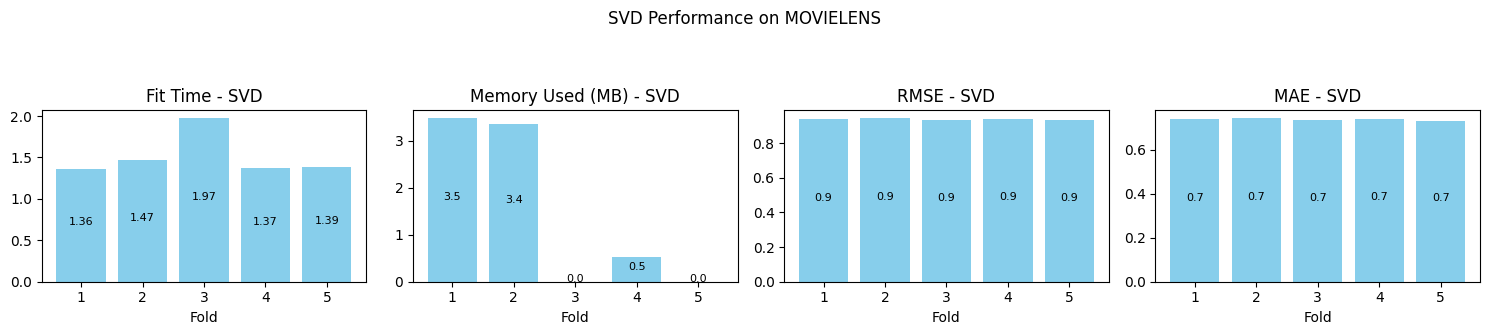


--------------------------------------------------
Evaluating KNNBasic on MOVIELENS
--------------------------------------------------
Computing the msd similarity matrix...
Done computing similarity matrix.
Fold 1 - Fit Time: 0.36s | Memory: 6.9MB | RMSE: 0.979 | MAE: 0.774
Computing the msd similarity matrix...
Done computing similarity matrix.
Fold 2 - Fit Time: 0.39s | Memory: 9.9MB | RMSE: 0.973 | MAE: 0.767
Computing the msd similarity matrix...
Done computing similarity matrix.
Fold 3 - Fit Time: 0.35s | Memory: 6.7MB | RMSE: 0.985 | MAE: 0.779
Computing the msd similarity matrix...
Done computing similarity matrix.
Fold 4 - Fit Time: 0.35s | Memory: 0.0MB | RMSE: 0.977 | MAE: 0.768
Computing the msd similarity matrix...
Done computing similarity matrix.
Fold 5 - Fit Time: 0.36s | Memory: 0.0MB | RMSE: 0.982 | MAE: 0.778


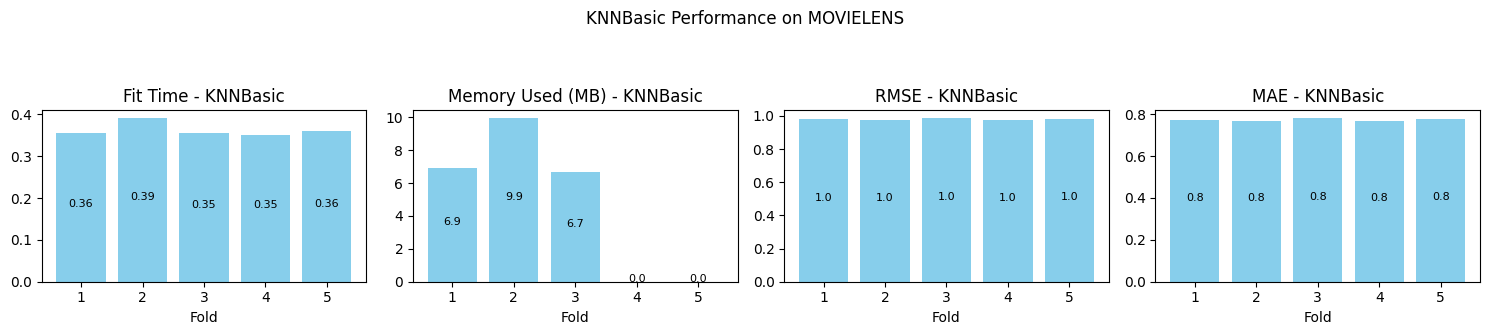


--------------------------------------------------
Evaluating NMF on MOVIELENS
--------------------------------------------------
Fold 1 - Fit Time: 2.34s | Memory: 0.0MB | RMSE: 0.967 | MAE: 0.758
Fold 2 - Fit Time: 2.18s | Memory: 0.0MB | RMSE: 0.967 | MAE: 0.760
Fold 3 - Fit Time: 2.16s | Memory: 0.0MB | RMSE: 0.967 | MAE: 0.761
Fold 4 - Fit Time: 2.19s | Memory: 0.0MB | RMSE: 0.959 | MAE: 0.757
Fold 5 - Fit Time: 2.89s | Memory: 0.0MB | RMSE: 0.970 | MAE: 0.761


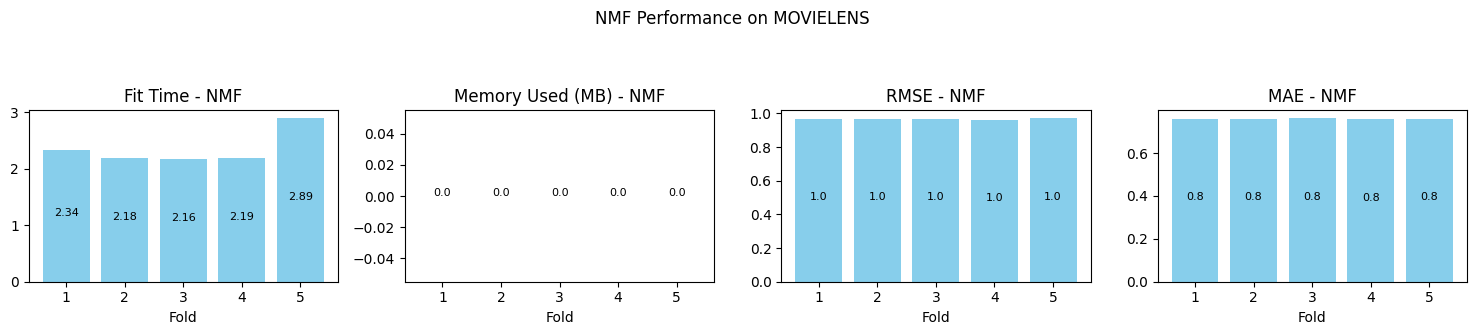


############################################################
MOVIELENS Final Summary:


,Algorithm,Fit Time,Memory Used (MB),RMSE,MAE
0,KNNBasic,0.362,4.716,0.979,0.773
1,NMF,2.352,0.000,0.966,0.759
2,SVD,1.511,1.468,0.936,0.738


In [ ]:
run_experiment('movielens')



############################################################
Starting JESTER Evaluation
############################################################


--------------------------------------------------
Evaluating SVD on JESTER
--------------------------------------------------
Fold 1 - Fit Time: 32.27s | Memory: 41.2MB | RMSE: 4.135 | MAE: 3.210
Fold 2 - Fit Time: 33.73s | Memory: 30.3MB | RMSE: 4.103 | MAE: 3.190
Fold 3 - Fit Time: 33.14s | Memory: -41.9MB | RMSE: 4.112 | MAE: 3.195
Fold 4 - Fit Time: 34.02s | Memory: 29.9MB | RMSE: 4.138 | MAE: 3.213
Fold 5 - Fit Time: 34.03s | Memory: -39.0MB | RMSE: 4.103 | MAE: 3.188


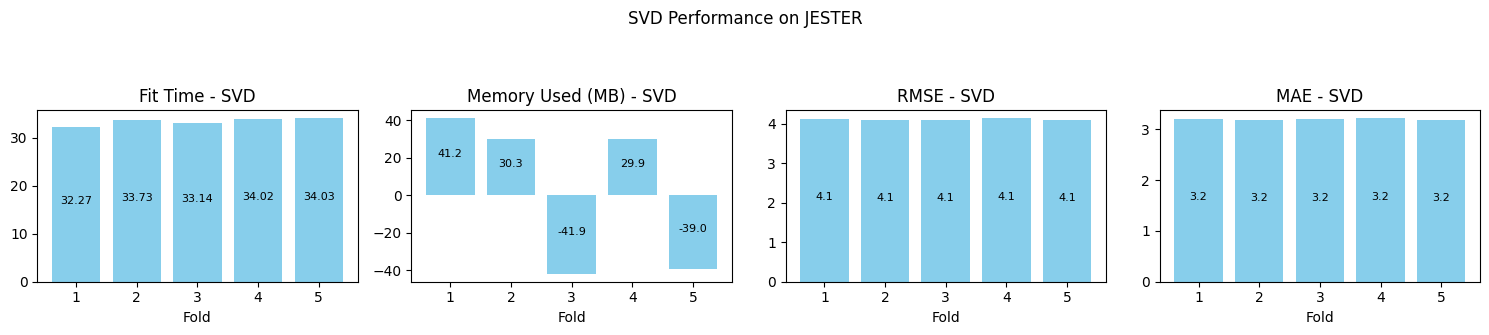


--------------------------------------------------
Evaluating NMF on JESTER
--------------------------------------------------
Fold 1 - Fit Time: 54.84s | Memory: 24.7MB | RMSE: 5.961 | MAE: 5.077
Fold 2 - Fit Time: 55.86s | Memory: 16.5MB | RMSE: 5.955 | MAE: 5.074
Fold 3 - Fit Time: 55.58s | Memory: 0.0MB | RMSE: 5.968 | MAE: 5.078
Fold 4 - Fit Time: 54.89s | Memory: 0.0MB | RMSE: 5.959 | MAE: 5.076
Fold 5 - Fit Time: 56.44s | Memory: 0.0MB | RMSE: 5.939 | MAE: 5.061


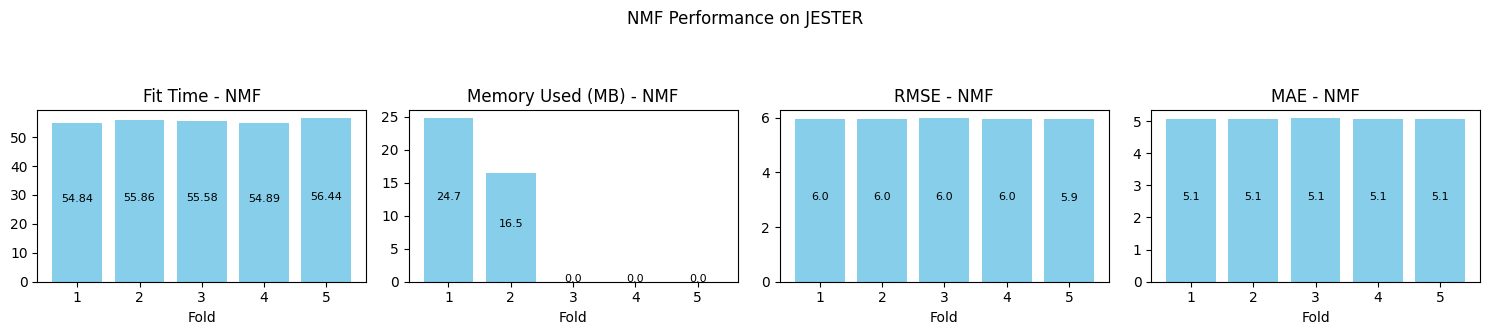


############################################################
JESTER Final Summary:


,Algorithm,Fit Time,Memory Used (MB),RMSE,MAE
0,NMF,55.525,8.245,5.956,5.073
1,SVD,33.437,4.078,4.118,3.199


In [ ]:
run_experiment('jester')
